In [2]:
from inspect_results import load_best_results, load_full_results
import numpy as np
import pandas as pd
import os

import sys
sys.path.append('/home/naliseas-workstation/Documents/haitong/diffusion-model-hallucination/gaussian_experiments/utils')
from inspect_results import load_best_results, load_full_results
import matplotlib.pyplot as plt


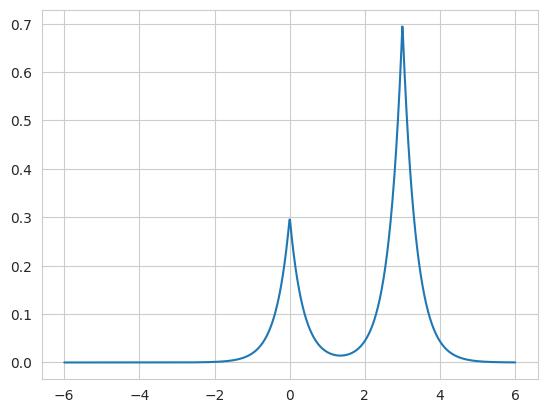

max reward:  0.6951712075742065


In [3]:
def get_max_regret(energy_fn):
    x = np.linspace(-10, 10, 1000)
    y = energy_fn(x)
    return np.max(y)

from energy_funcs import EnergyFunctionsRegistry

x = np.linspace(-6, 6, 1000)
energy_fn = EnergyFunctionsRegistry.get("energy_func_two_cusps")
plt.plot(x, energy_fn(x, l=0.6))
plt.show()
max_reward = get_max_regret(energy_fn)
print("max reward: ", max_reward)




In [4]:
all_results_df = []
logdir = '/home/naliseas-workstation/Documents/haitong/diffusion-model-hallucination/chkpts/20260127_shape_cusps_v2_exploration'
# for weight_pre_transform_fn in ["substract_min", "standarize-relu", "standarize-substract_min"]:
for weights_transform_fn in ["softmax", "group_relative_relu_linear", "group_relative_relu_quadratic"]:
    for initial_mean in [0.0, ]:
        pattern = fr".*reweighting_rl.*w{weights_transform_fn}.*im{initial_mean}.*$"
        df = load_full_results(pattern, logdir=logdir)
        if df is not None:
            print("weights_transform_fn: ", weights_transform_fn)
            # print(df.head())
            df['initial_mean'] = initial_mean
            df['weights_transform_fn'] = weights_transform_fn
            df['noise'] = 0.05
            all_results_df.append(df)
            
logdir2 = '/home/naliseas-workstation/Documents/haitong/diffusion-model-hallucination/chkpts/20260127_shape_cusps_v2_exploration_reproduce'
# for weight_pre_transform_fn in ["substract_min", "standarize-relu", "standarize-substract_min"]:
for weights_transform_fn in ['group_relative_negative_linear', "softmax_negative", "group_relative_negative_quadratic"]:
    for initial_mean in [0.0, ]:
        pattern = fr".*reweighting_rl.*w{weights_transform_fn}.*im{initial_mean}.*$"
        df = load_full_results(pattern, logdir=logdir2)
        if df is not None:
            print("weights_transform_fn: ", weights_transform_fn)
            # print(df.head())
            df['initial_mean'] = initial_mean
            df['weights_transform_fn'] = weights_transform_fn
            df['noise'] = 0.05
            all_results_df.append(df)
all_results_df_sweep_initial_noise_scale = pd.concat(all_results_df)
all_results_df_sweep_initial_noise_scale['regret'] = max_reward - all_results_df_sweep_initial_noise_scale['energy_mean']
all_results_df_sweep_initial_noise_scale['epoch'] = all_results_df_sweep_initial_noise_scale['epoch'] - 300

$0.520 \pm 0.188$
weights_transform_fn:  softmax
$0.288 \pm 0.029$
weights_transform_fn:  group_relative_relu_linear
$0.531 \pm 0.188$
weights_transform_fn:  group_relative_relu_quadratic
$0.467 \pm 0.203$
weights_transform_fn:  group_relative_negative_linear
$0.656 \pm 0.089$
weights_transform_fn:  softmax_negative
$0.652 \pm 0.098$
weights_transform_fn:  group_relative_negative_quadratic


In [24]:
all_results_df_sweep_initial_noise_scale['weights_transform_fn'].unique()

array(['softmax', 'group_relative_relu_linear',
       'group_relative_relu_quadratic', 'group_relative_negative_linear',
       'softmax_negative', 'group_relative_negative_quadratic'],
      dtype=object)

|    |   epoch |   energy_mean |   energy_std |   energy_stderr | logdir                                                                                                                                                                                                                    |   initial_mean | weights_transform_fn   |   noise |   regret |
|---:|--------:|--------------:|-------------:|----------------:|:--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|---------------:|:-----------------------|--------:|---------:|
|  0 |       0 |     0.0868155 |    0.0814064 |     0.000804467 | /home/naliseas-workstation/Documents/haitong/diffusion-model-hallucination/chkpts/20260127_shape_cusps_v2_exploration/20260127_220850_reweighting_rl_seed_44_add_noise_0.05_temp_0.1_s44_wsoftmax_im0.0_t0.1_l0.6_softmax |              0 |

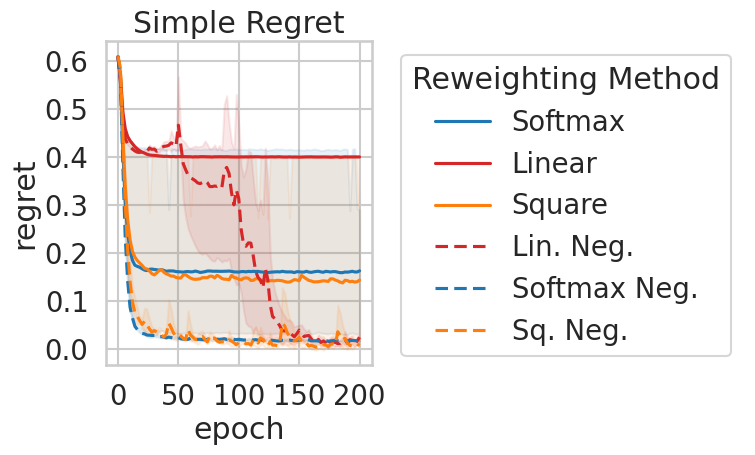

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
with sns.plotting_context('talk', font_scale=1.2):
    for initial_mean in all_results_df_sweep_initial_noise_scale['initial_mean'].unique():
        df = all_results_df_sweep_initial_noise_scale[all_results_df_sweep_initial_noise_scale['initial_mean'] == initial_mean].reset_index(drop=True)
        print(df.head().to_markdown())
        fig, (ax, legend_ax) = plt.subplots(1, 2, figsize=(8, 5))
        # Assign line color and style by hue: use palette for color, pass list of dashes for style
        # Rename color_dict/dash_dict keys and lineplot palette/dashes so keys (and orders) match the displayed legend_label
        color_dict = {
            'Softmax': 'tab:blue',
            'Linear': 'tab:red',
            'Square': 'tab:orange',
            'Lin. Neg.': 'tab:red',
            'Softmax Neg.': 'tab:blue',
            'Sq. Neg.': 'tab:orange'
        }
        dash_dict = {
            'Softmax': '',  # solid line
            'Linear': '', # solid
            'Square': '', # solid
            'Lin. Neg.': (4,2), # dashed
            'Softmax Neg.': (4,2), # dashed
            'Sq. Neg.': (4,2) # dashed
        }
        df['legend_label'] = df['weights_transform_fn'].map({
            'softmax': 'Softmax',
            'group_relative_relu_linear': 'Linear',
            'group_relative_relu_quadratic': 'Square',
            'group_relative_negative_linear': 'Lin. Neg.',
            'softmax_negative': 'Softmax Neg.',
            'group_relative_negative_quadratic': 'Sq. Neg.'
        }).fillna(df['weights_transform_fn'])
        custom_hue_order = [
            'Softmax',
            'Linear',
            'Square',
            'Lin. Neg.',
            'Softmax Neg.',
            'Sq. Neg.'
        ]
        sns.lineplot(
            x='epoch',
            y='regret',
            data=df,
            hue='legend_label',
            hue_order=custom_hue_order,
            style='legend_label',
            palette=color_dict,
            dashes=dash_dict,
            ax=ax,
            err_kws={'alpha': 0.1}
        )
        # h, l = ax.get_legend_handles_labels()
        # ax.legend(h, ['identity', 'quadratic', 'softmax'], title='Weights')
        # ax.set_yscale('log')
        ax.set_title(f'Simple Regret')
        h, l = ax.get_legend_handles_labels()
        ax.legend().remove()
        legend_ax.legend(h, l, title='Reweighting Method')
        legend_ax.axis('off')
        plt.tight_layout()
        plt.savefig(f'regret_plot_log_energy_cusps_im{initial_mean}_neg.pdf', dpi=300)



In [20]:
all_results_df = []
logdir = '/home/naliseas-workstation/Documents/haitong/diffusion-model-hallucination/chkpts/20260126_shape_cusps_v2'
# for weight_pre_transform_fn in ["substract_min", "standarize-relu", "standarize-substract_min"]:
for weights_transform_fn in ["relu_normalize", "quad_relu_normalize", "softmax", "group_relative_relu_linear", "group_relative_relu_quadratic"]:
    for initial_mean in [0.0, 1.0, 2.0]:
        pattern = fr".*reweighting_rl.*w{weights_transform_fn}.*im{initial_mean}.*$"
        df = load_full_results(pattern, logdir=logdir)
        if df is not None:
            print("weights_transform_fn: ", weights_transform_fn)
            # print(df.head())
            df['initial_mean'] = initial_mean
            df['weights_transform_fn'] = weights_transform_fn
            df['noise'] = 0.05
            all_results_df.append(df)
all_results_df_sweep_initial_noise_scale = pd.concat(all_results_df)
all_results_df_sweep_initial_noise_scale['regret'] = max_reward - all_results_df_sweep_initial_noise_scale['energy_mean']
all_results_df_sweep_initial_noise_scale['epoch'] = all_results_df_sweep_initial_noise_scale['epoch'] - 300

$0.506 \pm 0.194$
weights_transform_fn:  softmax
$0.626 \pm 0.113$
weights_transform_fn:  softmax
$0.629 \pm 0.098$
weights_transform_fn:  softmax
$0.282 \pm 0.039$
weights_transform_fn:  group_relative_relu_linear
$0.629 \pm 0.122$
weights_transform_fn:  group_relative_relu_linear
$0.632 \pm 0.108$
weights_transform_fn:  group_relative_relu_linear
$0.511 \pm 0.193$
weights_transform_fn:  group_relative_relu_quadratic
$0.628 \pm 0.117$
weights_transform_fn:  group_relative_relu_quadratic
$0.628 \pm 0.105$
weights_transform_fn:  group_relative_relu_quadratic


|    |   epoch |   energy_mean |   energy_std |   energy_stderr | logdir                                                                                                                                                                                                        |   initial_mean | weights_transform_fn   |   noise |   regret |
|---:|--------:|--------------:|-------------:|----------------:|:--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|---------------:|:-----------------------|--------:|---------:|
|  0 |       0 |     0.0860718 |    0.0810382 |     0.000800829 | /home/naliseas-workstation/Documents/haitong/diffusion-model-hallucination/chkpts/20260126_shape_cusps_v2/20260126_003611_reweighting_rl_seed_42_add_noise_0.05_temp_0.1_s42_wsoftmax_im0.0_t0.1_l0.8_softmax |              0 | softmax                |    0.05 | 

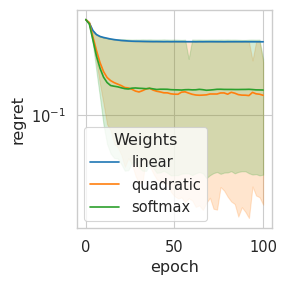

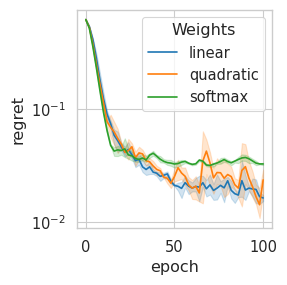

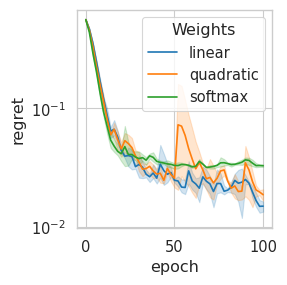

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_context('paper', font_scale=1.2)
for initial_mean in all_results_df_sweep_initial_noise_scale['initial_mean'].unique():
    df = all_results_df_sweep_initial_noise_scale[all_results_df_sweep_initial_noise_scale['initial_mean'] == initial_mean].reset_index(drop=True)
    # df.sort_values(by='weights_transform_fn', inplace=True,)
    print(df.head().to_markdown())
    fig, ax = plt.subplots(1, 1, figsize=(3, 3))
    sns.lineplot(
        x='epoch',
        y='regret',
        data=df,
        hue='weights_transform_fn',
        hue_order=['group_relative_relu_linear', 'group_relative_relu_quadratic', 'softmax'],
        ax=ax
    )
    h, l = ax.get_legend_handles_labels()
    ax.legend(h, ['linear', 'quadratic','softmax', ], title='Weights')
    ax.set_yscale('log')
    # ax.set_title(f'Initial mean: {initial_mean}')
    plt.tight_layout()
    plt.savefig(f'regret_plot_log_energy_cusps_im{initial_mean}.pdf', dpi=300)



In [23]:
all_results_df = []
l = 0.1
logdir = '/home/naliseas-workstation/Documents/haitong/diffusion-model-hallucination/chkpts/20260125_two_gaussian_small_l_fixed_eval'
# for weight_pre_transform_fn in ["substract_min", "standarize-relu", "standarize-substract_min"]:
for weights_transform_fn in ["relu_normalize", "quad_relu_normalize", "softmax"]:
    for initial_mean in [0.0, 1.0, 2.0]:
        for l in [0.1, 0.2, 0.3]:
            pattern = fr".*reweighting_rl.*w{weights_transform_fn}.*im{initial_mean}.*l{l}.*$"
            df = load_full_results(pattern, logdir=logdir)
            if df is not None:
                print(df.head())
                df['initial_mean'] = initial_mean
                df['weights_transform_fn'] = weights_transform_fn
                df['noise'] = 0.05
                df['l'] = l
                df['regret'] = max_rewards[l] - df['energy_mean']
                all_results_df.append(df)
all_results_df_sweep_initial_noise_scale = pd.concat(all_results_df)
# all_results_df_sweep_initial_noise_scale['regret'] = max_reward - all_results_df_sweep_initial_noise_scale['energy_mean']
all_results_df_sweep_initial_noise_scale['epoch'] = all_results_df_sweep_initial_noise_scale['epoch'] - 300

$0.270 \pm 0.053$
   epoch  energy_mean  energy_std  energy_stderr  \
0    300     0.023173    0.066826       0.000660   
1    302     0.051140    0.094859       0.000937   
2    304     0.153707    0.128653       0.001271   
3    306     0.199424    0.119347       0.001179   
4    308     0.227878    0.103908       0.001027   

                                              logdir  
0  /home/naliseas-workstation/Documents/haitong/d...  
1  /home/naliseas-workstation/Documents/haitong/d...  
2  /home/naliseas-workstation/Documents/haitong/d...  
3  /home/naliseas-workstation/Documents/haitong/d...  
4  /home/naliseas-workstation/Documents/haitong/d...  
$0.280 \pm 0.044$
   epoch  energy_mean  energy_std  energy_stderr  \
0    300     0.046246    0.088720       0.000877   
1    302     0.107708    0.118279       0.001169   
2    304     0.205598    0.113486       0.001121   
3    306     0.239443    0.092282       0.000912   
4    308     0.257314    0.074679       0.000738   

        

Initial mean: 0.0, l: 0.1
Initial mean: 1.0, l: 0.1
Initial mean: 2.0, l: 0.1
Initial mean: 0.0, l: 0.2
Initial mean: 1.0, l: 0.2
Initial mean: 2.0, l: 0.2
Initial mean: 0.0, l: 0.3
Initial mean: 1.0, l: 0.3
Initial mean: 2.0, l: 0.3


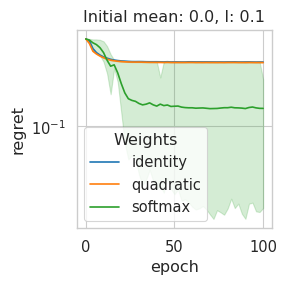

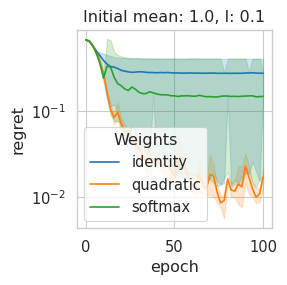

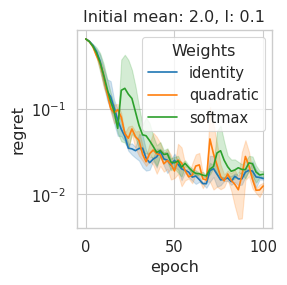

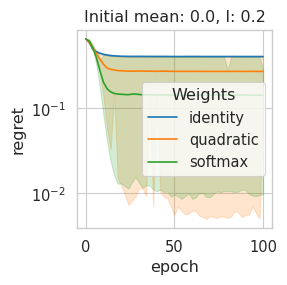

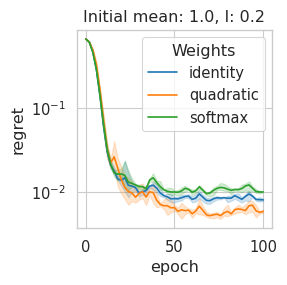

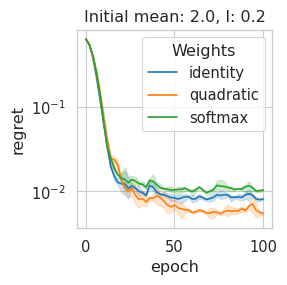

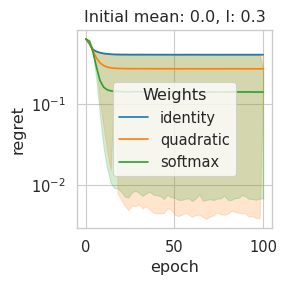

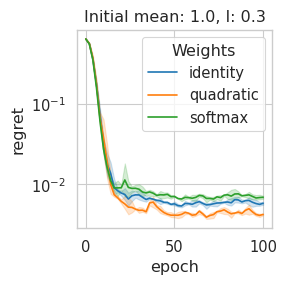

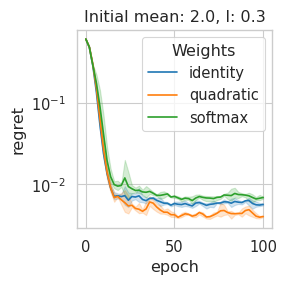

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_context('paper', font_scale=1.2)
for energy_fn_kwargs_l in all_results_df_sweep_initial_noise_scale['l'].unique():
    for initial_mean in all_results_df_sweep_initial_noise_scale['initial_mean'].unique():
        print(f"Initial mean: {initial_mean}, l: {energy_fn_kwargs_l}")
        df = all_results_df_sweep_initial_noise_scale[
            (all_results_df_sweep_initial_noise_scale['initial_mean'] == initial_mean) & 
            (all_results_df_sweep_initial_noise_scale['l'] == energy_fn_kwargs_l)
        ].reset_index(drop=True)
        # print(df.head().to_markdown())
        fig, ax = plt.subplots(1, 1, figsize=(3, 3))
        sns.lineplot(x='epoch', y='regret', data=df, hue='weights_transform_fn', ax=ax)
        h, l = ax.get_legend_handles_labels()
        ax.legend(h, ['identity', 'quadratic', 'softmax'], title='Weights')
        ax.set_yscale('log')
        ax.set_title(f'Initial mean: {initial_mean}, l: {energy_fn_kwargs_l}')
        plt.tight_layout()
        plt.savefig(f'regret_plot_log_energy_im{initial_mean}_l{l}.pdf', dpi=300)



$0.294 \pm 0.009$
$0.675 \pm 0.076$
$0.674 \pm 0.072$
$0.672 \pm 0.070$
$0.681 \pm 0.072$
$0.680 \pm 0.069$
$0.678 \pm 0.069$
$0.677 \pm 0.069$
$0.373 \pm 0.086$
$0.410 \pm 0.057$
$0.361 \pm 0.078$
$0.402 \pm 0.039$
Weights transform fn: relu_normalize, number of unique logdirs: 4
Weights transform fn: quad_relu_normalize, number of unique logdirs: 4
Weights transform fn: softmax, number of unique logdirs: 4


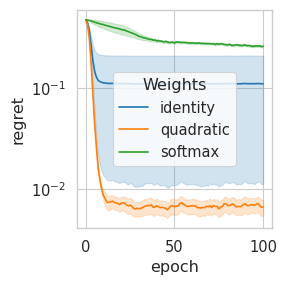

In [7]:
def collect_toy_results(logdir):

    all_results_df = []
    # for weight_pre_transform_fn in ["substract_min", "standarize-relu", "standarize-substract_min"]:
    for weights_transform_fn in ["relu_normalize", "quad_relu_normalize", "softmax"]:
        for energy_fn_kwargs_l in [0.8, 1.0, 1.2, 1.4]:
            pattern = fr".*reweighting_rl.*energy_fn_kwargs_l_{energy_fn_kwargs_l}_{weights_transform_fn}.*$"
            df = load_full_results(pattern, logdir=logdir)
            if df is not None:
                # all_results_df.append({
                #     # 'weight_pre_transform_fn': weight_pre_transform_fn,
                #     'weights_transform_fn': weights_transform_fn,
                #     'mean': df['energy_mean'].mean(),
                #     'std': df['energy_mean'].std(),
                #     'se': df['energy_mean'].std() / np.sqrt(len(df)),
                #     'noise': 0.2,
                #     'energy_fn_kwargs_l': energy_fn_kwargs_l,
                #     'display': f"{df['energy_mean'].mean():.0f} $\pm$ {df['energy_mean'].std()/ np.sqrt(len(df)) :.0f}",
                # })
                # print(df.head())
                df['energy_fn_kwargs_l'] = energy_fn_kwargs_l
                df['weights_transform_fn'] = weights_transform_fn
                df['noise'] = 0.4
                all_results_df.append(df)
    all_results_df_sweep_initial_noise_scale = pd.concat(all_results_df)
    all_results_df_sweep_initial_noise_scale['regret'] = 0.7005724067912344 - all_results_df_sweep_initial_noise_scale['energy_mean']
    all_results_df_sweep_initial_noise_scale['epoch'] = all_results_df_sweep_initial_noise_scale['epoch'] - 300
    sns.set_context('paper', font_scale=1.2)
    fig, ax = plt.subplots(1, 1, figsize=(3, 3))
    for fn in all_results_df_sweep_initial_noise_scale['weights_transform_fn'].unique():
        unique_logdirs = all_results_df_sweep_initial_noise_scale.loc[
            all_results_df_sweep_initial_noise_scale['weights_transform_fn'] == fn, 'logdir'].nunique()
        print(f"Weights transform fn: {fn}, number of unique logdirs: {unique_logdirs}")
    sns.lineplot(x='epoch', y='regret', data=all_results_df_sweep_initial_noise_scale, errorbar='se', hue='weights_transform_fn', ax=ax)
    h, l = ax.get_legend_handles_labels()
    ax.legend(h, ['identity', 'quadratic', 'softmax'], title='Weights')
    ax.set_yscale('log')
    plt.tight_layout()
    plt.savefig(os.path.join(logdir, 'regret_plot.pdf'), dpi=300)
    
logdir = '/home/naliseas-workstation/Documents/haitong/diffusion-model-hallucination/chkpts/sweep_energy_fn_kwargs_l_initial_mean_0.0'
collect_toy_results(logdir)


$0.487 \pm 0.200$
   epoch  energy_mean  energy_std  energy_stderr  \
0    300     0.232562    0.079436       0.000785   
1    301     0.243048    0.068773       0.000680   
2    302     0.262174    0.050624       0.000500   
3    303     0.276903    0.037396       0.000370   
4    304     0.284033    0.028979       0.000286   

                                              logdir  
0  /home/naliseas-workstation/Documents/haitong/d...  
1  /home/naliseas-workstation/Documents/haitong/d...  
2  /home/naliseas-workstation/Documents/haitong/d...  
3  /home/naliseas-workstation/Documents/haitong/d...  
4  /home/naliseas-workstation/Documents/haitong/d...  
$0.678 \pm 0.073$
   epoch  energy_mean  energy_std  energy_stderr  \
0    300     0.230066    0.080683       0.000797   
1    301     0.285628    0.128742       0.001272   
2    302     0.405231    0.182273       0.001801   
3    303     0.530560    0.157843       0.001560   
4    304     0.623882    0.095817       0.000947   

        

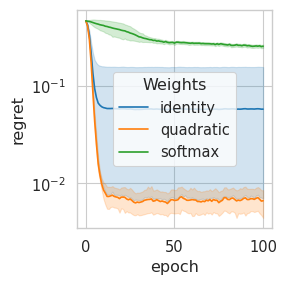

In [31]:
logdir = '/home/naliseas-workstation/Documents/haitong/diffusion-model-hallucination/chkpts/sweep_energy_fn_kwargs_l_initial_mean_0.0'
collect_toy_results(logdir)

$0.682 \pm 0.049$
$0.681 \pm 0.044$
$0.679 \pm 0.041$
$0.677 \pm 0.077$
$0.685 \pm 0.044$
$0.683 \pm 0.043$
$0.681 \pm 0.045$
$0.679 \pm 0.043$
$0.676 \pm 0.042$
Weights transform fn: relu_normalize, number of unique logdirs: 3
Weights transform fn: quad_relu_normalize, number of unique logdirs: 3
Weights transform fn: softmax, number of unique logdirs: 3


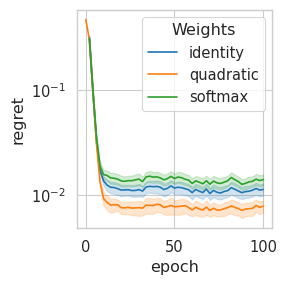

In [ ]:
logdir = '/home/naliseas-workstation/Documents/haitong/diffusion-model-hallucination/chkpts/sweep_energy_fn_kwargs_l_initial_mean_0.0_fixed_softmax'
collect_toy_results(logdir)

$0.682 \pm 0.049$
$0.681 \pm 0.044$
$0.679 \pm 0.041$
$0.687 \pm 0.042$
$0.685 \pm 0.044$
$0.683 \pm 0.043$
$0.681 \pm 0.045$
$0.679 \pm 0.043$
$0.676 \pm 0.042$
Weights transform fn: relu_normalize, number of unique logdirs: 3
Weights transform fn: quad_relu_normalize, number of unique logdirs: 3
Weights transform fn: softmax, number of unique logdirs: 3


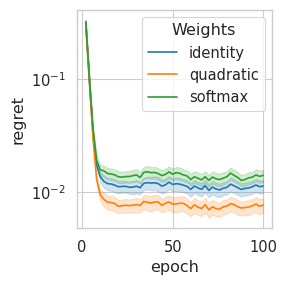

In [39]:
logdir = '/home/naliseas-workstation/Documents/haitong/diffusion-model-hallucination/chkpts/sweep_energy_fn_kwargs_l_initial_mean_1.0_fixed_softmax'
collect_toy_results(logdir)

$0.682 \pm 0.049$
$0.681 \pm 0.044$
$0.679 \pm 0.041$
$0.687 \pm 0.042$
$0.684 \pm 0.044$
$0.683 \pm 0.043$
$0.681 \pm 0.045$
$0.678 \pm 0.043$
$0.676 \pm 0.042$
Weights transform fn: relu_normalize, number of unique logdirs: 4
Weights transform fn: quad_relu_normalize, number of unique logdirs: 4
Weights transform fn: softmax, number of unique logdirs: 4


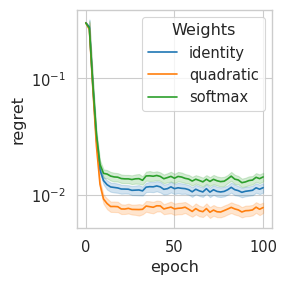

In [40]:
logdir = '/home/naliseas-workstation/Documents/haitong/diffusion-model-hallucination/chkpts/sweep_energy_fn_kwargs_l_initial_mean_2.0_fixed_softmax'
collect_toy_results(logdir)

$0.690 \pm 0.030$
$0.690 \pm 0.046$
$0.691 \pm 0.031$
Weights transform fn: relu_normalize, number of unique logdirs: 3
Weights transform fn: quad_relu_normalize, number of unique logdirs: 3
Weights transform fn: softmax, number of unique logdirs: 3
$0.690 \pm 0.030$
$0.693 \pm 0.031$
$0.691 \pm 0.031$
Weights transform fn: relu_normalize, number of unique logdirs: 3
Weights transform fn: quad_relu_normalize, number of unique logdirs: 3
Weights transform fn: softmax, number of unique logdirs: 3
$0.690 \pm 0.030$
$0.690 \pm 0.046$
$0.691 \pm 0.031$
Weights transform fn: relu_normalize, number of unique logdirs: 3
Weights transform fn: quad_relu_normalize, number of unique logdirs: 3
Weights transform fn: softmax, number of unique logdirs: 3


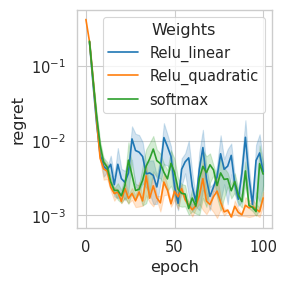

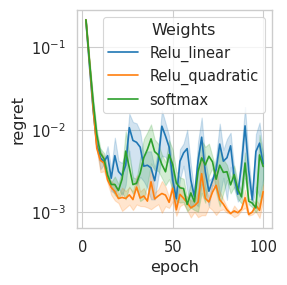

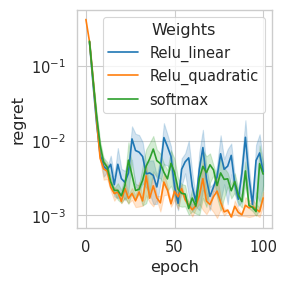

In [53]:
def collect_toy_results(logdir):

    all_results_df = []
    # for weight_pre_transform_fn in ["substract_min", "standarize-relu", "standarize-substract_min"]:
    for weights_transform_fn in ["relu_normalize", "quad_relu_normalize", "softmax"]:
        # for energy_fn_kwargs_l in [0.8, 1.0, 1.2, 1.4]:
        pattern = fr".*reweighting_rl.*energy_fn_kwargs_l__{weights_transform_fn}.*$"
        df = load_full_results(pattern, logdir=logdir)
        if df is not None:
            # all_results_df.append({
            #     # 'weight_pre_transform_fn': weight_pre_transform_fn,
            #     'weights_transform_fn': weights_transform_fn,
            #     'mean': df['energy_mean'].mean(),
            #     'std': df['energy_mean'].std(),
            #     'se': df['energy_mean'].std() / np.sqrt(len(df)),
            #     'noise': 0.2,
            #     'energy_fn_kwargs_l': energy_fn_kwargs_l,
            #     'display': f"{df['energy_mean'].mean():.0f} $\pm$ {df['energy_mean'].std()/ np.sqrt(len(df)) :.0f}",
            # })
            # print(df.head())
            df['energy_fn_kwargs_l'] = energy_fn_kwargs_l
            df['weights_transform_fn'] = weights_transform_fn
            df['noise'] = 0.4
            # EMA smoothing for energy_mean for each logdir
            # if 'logdir' in df.columns:
            #     ema_alpha = 0.2
            #     df = df.sort_values(['logdir', 'epoch'])
            #     df['energy_mean_smooth'] = df.groupby('logdir')['energy_mean'].transform(
            #         lambda x: x.ewm(alpha=ema_alpha, adjust=False).mean()
            #     )
            all_results_df.append(df)
    all_results_df_sweep_initial_noise_scale = pd.concat(all_results_df)
    all_results_df_sweep_initial_noise_scale['regret'] = 0.7005724067912344 - all_results_df_sweep_initial_noise_scale['energy_mean']
    all_results_df_sweep_initial_noise_scale['epoch'] = all_results_df_sweep_initial_noise_scale['epoch'] - 300
    sns.set_context('paper', font_scale=1.2)
    fig, ax = plt.subplots(1, 1, figsize=(3, 3))
    for fn in all_results_df_sweep_initial_noise_scale['weights_transform_fn'].unique():
        unique_logdirs = all_results_df_sweep_initial_noise_scale.loc[
            all_results_df_sweep_initial_noise_scale['weights_transform_fn'] == fn, 'logdir'].nunique()
        print(f"Weights transform fn: {fn}, number of unique logdirs: {unique_logdirs}")
    sns.lineplot(x='epoch', y='regret', data=all_results_df_sweep_initial_noise_scale, errorbar='se', hue='weights_transform_fn', ax=ax)
    h, l = ax.get_legend_handles_labels()
    ax.legend(h, ['Relu_linear', 'Relu_quadratic', 'softmax'], title='Weights')
    ax.set_yscale('log')
    plt.tight_layout()
    plt.savefig(os.path.join(logdir, 'regret_plot.pdf'), dpi=300)
    
logdir = '/home/naliseas-workstation/Documents/haitong/diffusion-model-hallucination/chkpts/sweep_energy_fn_kwargs_l_initial_mean_1.0_fixed_softmax_v2'
collect_toy_results(logdir)
logdir = '/home/naliseas-workstation/Documents/haitong/diffusion-model-hallucination/chkpts/sweep_energy_fn_kwargs_l_initial_mean_0.0_fixed_softmax_v2'
collect_toy_results(logdir)
logdir = '/home/naliseas-workstation/Documents/haitong/diffusion-model-hallucination/chkpts/sweep_energy_fn_kwargs_l_initial_mean_1.0_fixed_softmax_v2'
collect_toy_results(logdir)